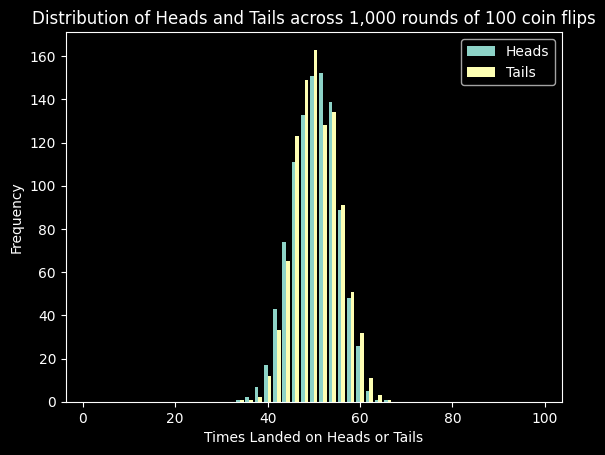

In [ ]:
# Coin toss simultor with the results displayed
# in a a distribution histogram

import random
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# Define function for parallel processing of
# simulated coin flips for a distribution

def flip_rounds(flips):
        heads = 0
        tails = 0
        for _ in range(flips):
            coin_flip = random.randint(1, 2)
            if coin_flip == 1:
                heads += 1
            else:
                tails += 1
        return(heads, tails)

rounds = 1_000
flips = 100

with ProcessPoolExecutor(max_workers=30) as executor:
    all_results = list(executor.map(flip_rounds, [flips]*rounds))

'''
all_results = []
rounds = 0

for _ in range(5000000):
    heads = 0
    tails = 0
    flips = 0

    while flips < 1000:
        coin_flip = random.randint(1, 2)
        flips += 1
        if coin_flip == 1:
            heads += 1
        else:
            tails += 1

    rounds += 1
    all_results.append((heads, tails))

all_results'''


# Seperate Heads and Tails so we can display them in
# a histogram
heads_list = [result[0] for result in all_results]
tails_list = [result[1] for result in all_results]

plt.hist([heads_list, tails_list], bins=range(
    1, 101, 2), label=['Heads', 'Tails'])
plt.xlabel('Times Landed on Heads or Tails')
plt.ylabel('Frequency')
plt.title(
    f'Distribution of Heads and Tails across {rounds:,} rounds of {flips} coin flips')
plt.legend()
plt.show()

# Tracking Hardway's of dice throws

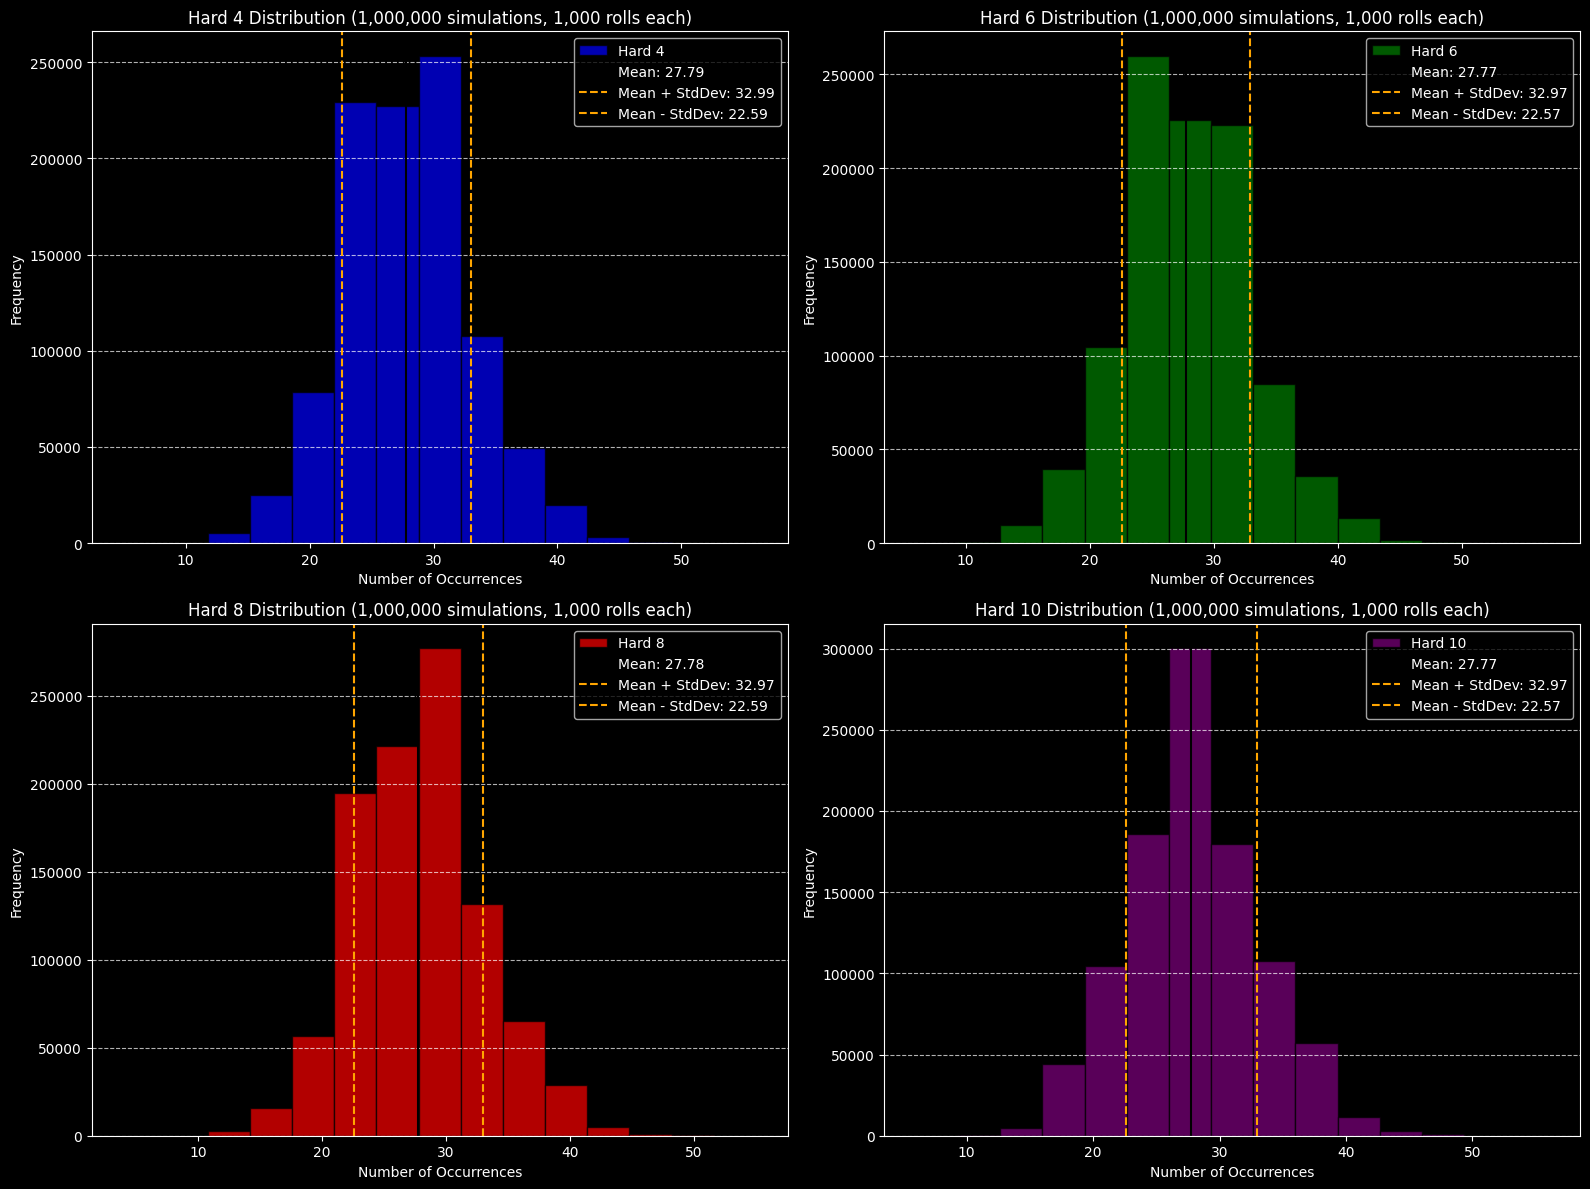


Overall Statistics:
Hard 4:
  Mean: 27.79
  Standard Deviation: 5.20
  Expected Theoretical: 27.78
Hard 6:
  Mean: 27.77
  Standard Deviation: 5.20
  Expected Theoretical: 27.78
Hard 8:
  Mean: 27.78
  Standard Deviation: 5.19
  Expected Theoretical: 27.78
Hard 10:
  Mean: 27.77
  Standard Deviation: 5.20
  Expected Theoretical: 27.78


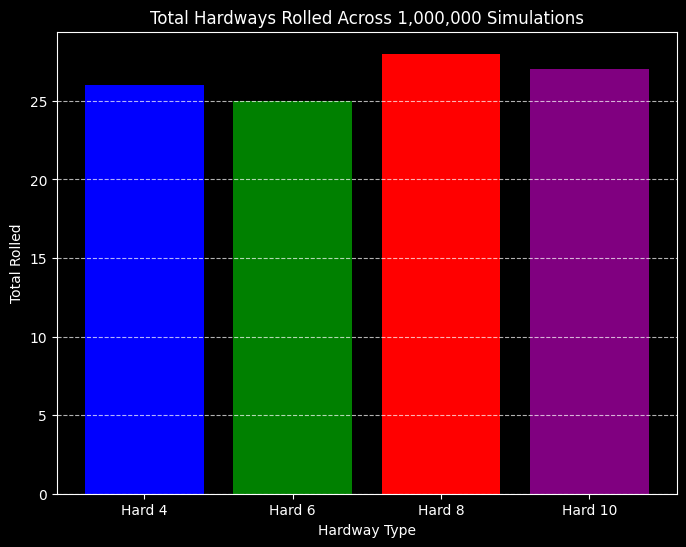

Total hardways rolled across all simulations:
Hard 4: 26
Hard 6: 25
Hard 8: 28
Hard 10: 27


In [20]:
import random
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Number of simulations to run
num_simulations = 1000000
# Number of rolls per simulation
rolls_per_sim = 1000

# Store results of each simulation
simulation_results = []

# Run multiple simulations
for sim in range(num_simulations):
    rolls = 0
    hardway_counts = {"Hard 4": 0, "Hard 6": 0, "Hard 8": 0, "Hard 10": 0}
    total_hardways = {"Hard 4": 0, "Hard 6": 0, "Hard 8": 0, "Hard 10": 0,}

    # Roll dice rolls_per_sim times
    while rolls < rolls_per_sim:
        first_die = random.randint(1, 6)
        second_die = random.randint(1, 6)
        dice_sum = first_die + second_die

        # Check if the dice match (hardways)
        if first_die == second_die:
            if dice_sum == 4:  # (2+2)
                hardway_counts["Hard 4"] += 1
                total_hardways["Hard 4"] += 1
            elif dice_sum == 6:  # (3+3)
                hardway_counts["Hard 6"] += 1
                total_hardways["Hard 6"] += 1
            elif dice_sum == 8:  # (4+4)
                hardway_counts["Hard 8"] += 1
                total_hardways["Hard 8"] += 1
            elif dice_sum == 10:  # (5+5)
                hardway_counts["Hard 10"] += 1
                total_hardways["Hard 10"] += 1

        rolls += 1

    # Save this simulation's results
    simulation_results.append(hardway_counts)

# Extract data for each hardway across all simulations
hard_4_counts = [result["Hard 4"] for result in simulation_results]
hard_6_counts = [result["Hard 6"] for result in simulation_results]
hard_8_counts = [result["Hard 8"] for result in simulation_results]
hard_10_counts = [result["Hard 10"] for result in simulation_results]

# Create figure with 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

# Plot histograms for each hardway
hardway_data = [
    {"name": "Hard 4", "counts": hard_4_counts, "color": "blue", "index": 0},
    {"name": "Hard 6", "counts": hard_6_counts, "color": "green", "index": 1},
    {"name": "Hard 8", "counts": hard_8_counts, "color": "red", "index": 2},
    {"name": "Hard 10", "counts": hard_10_counts, "color": "purple", "index": 3}
]

for hw in hardway_data:
    ax = axs[hw["index"]]
    data = hw["counts"]

    # Calculate statistics
    mean_val = np.mean(data)
    std_val = np.std(data)

    # Create histogram
    ax.hist(data, bins=15, alpha=0.7, color=hw["color"],
            edgecolor="black", label=hw["name"])

    # Add vertical lines for mean and standard deviation
    ax.axvline(mean_val, color='black', linestyle='-',
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(mean_val + std_val, color='orange', linestyle='--',
               label=f'Mean + StdDev: {(mean_val + std_val):.2f}')
    ax.axvline(max(0, mean_val - std_val), color='orange', linestyle='--',
               label=f'Mean - StdDev: {max(0, mean_val - std_val):.2f}')

    # Set labels and title
    ax.set_title(f'{hw["name"]} Distribution ({num_simulations:,} simulations, {rolls_per_sim:,} rolls each)')
    ax.set_xlabel('Number of Occurrences')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()

# Print overall statistics
print("\nOverall Statistics:")
for hw in hardway_data:
    data = hw["counts"]
    print(f"{hw['name']}:")
    print(f"  Mean: {np.mean(data):.2f}")
    print(f"  Standard Deviation: {np.std(data):.2f}")
    print(f"  Expected Theoretical: {rolls_per_sim/36:.2f}")  # 1/36 probability for each hardway


# Bar graph of total hardways rolled across all simulations
plt.figure(figsize=(8, 6))
plt.bar(total_hardways.keys(), total_hardways.values(), color=['blue', 'green', 'red', 'purple'])
plt.title(f'Total Hardways Rolled Across {num_simulations:,} Simulations')
plt.xlabel('Hardway Type')
plt.ylabel('Total Rolled')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Total hardways rolled across all simulations:")
for k, v in total_hardways.items():
    print(f"{k}: {v}")